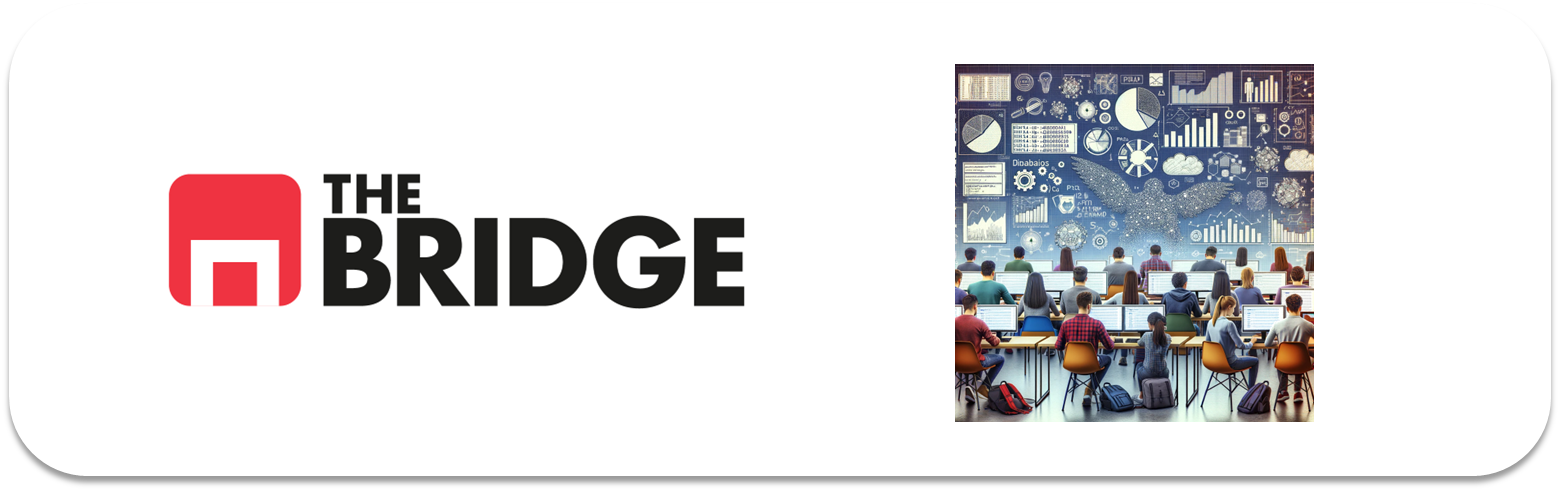

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [4]:
boston_housing = pd.read_csv('data/hard_to_find/obligatoria_hard.csv', sep='|')

In [6]:
boston_housing.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


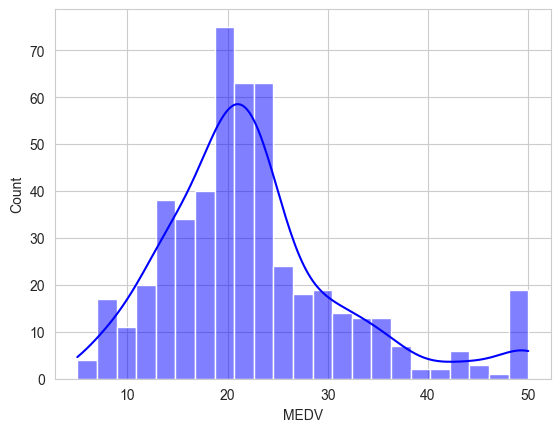

In [7]:
sns.histplot(boston_housing['MEDV'], color='Blue', kde = True)
plt.show()

La variable target sigue una distribución normal

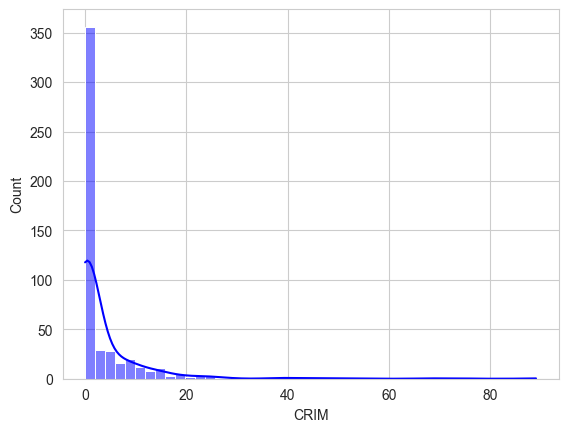

In [11]:
sns.histplot(boston_housing['CRIM'], color='Blue', kde = True)
plt.show()

In [13]:
boston_housing.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'LSTAT', 'MEDV'],
      dtype='str')

In [14]:
# Feautures
X = boston_housing[['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'LSTAT']]

# Target
y = boston_housing['MEDV']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(506, 12)
(404, 12)
(102, 12)
(404,)
(102,)


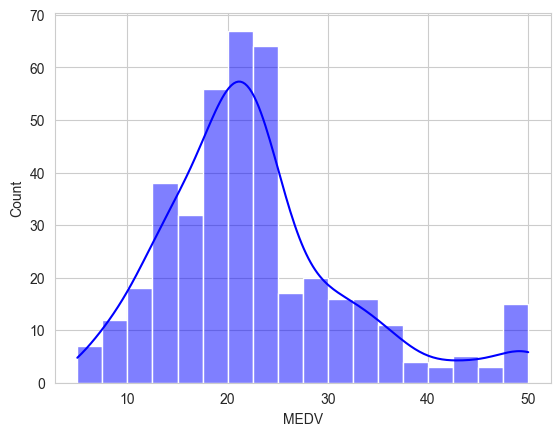

In [19]:
sns.histplot(y_train, color='Blue', kde = True)
plt.show()

In [36]:
df_train_corr = pd.concat([X_train, y_train], axis=1)

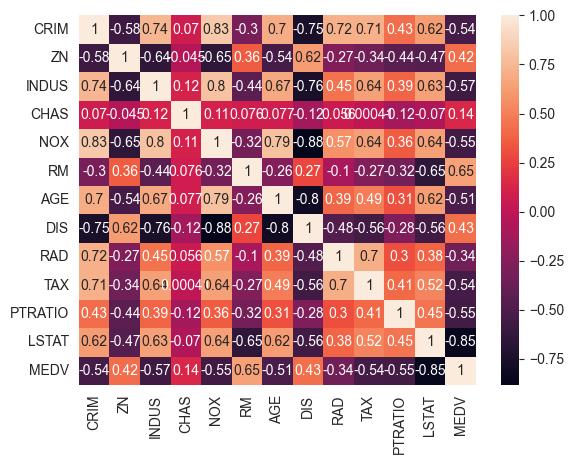

In [37]:
sns.heatmap(df_train_corr.corr(numeric_only=True, method='spearman'), annot=True)
plt.show()

Decide eliminar las variables con mayor número de colinearidades tanto positivas como negativas fuertes (>0.50): CRIM, INDUS, NOX, DIS, TAX y ZN, excluyendo a LSTAT porque es la más correlacionada con el target.

In [139]:
X_train_copy = X_train.copy()

In [140]:
X_train_copy= X_train_copy.drop(columns=['CRIM', 'INDUS', 'NOX', 'DIS', 'TAX', 'ZN'])

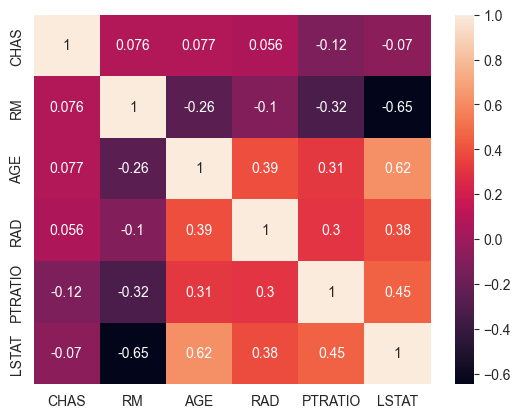

In [141]:
sns.heatmap(X_train_copy.corr(numeric_only=True, method='spearman'), annot=True)
plt.show()

In [142]:
X_train_copy.describe()

,CHAS,RM,AGE,RAD,PTRATIO,LSTAT
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,0.071782,6.315891,68.556436,9.356436,18.318317,12.457351
std,0.258447,0.709452,27.994922,8.589721,2.228701,7.110381
min,0.000000,3.863000,2.900000,1.000000,12.600000,1.730000
25%,0.000000,5.890500,45.550000,4.000000,16.800000,6.772500
50%,0.000000,6.210000,77.700000,5.000000,18.700000,10.925000
75%,0.000000,6.636750,93.650000,12.000000,20.200000,16.372500
max,1.000000,8.780000,100.000000,24.000000,22.000000,37.970000


Como hay mucha variabilidad, vamos a normalizar los datos

In [85]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

In [143]:
cols_a_escalar = [col for col in X_train_copy.columns if col != 'CHAS']

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', MinMaxScaler(), cols_a_escalar)
    ],
    remainder='passthrough'
)

X_transformed = preprocessor.fit_transform(X_train_copy)

# Reconstruir DataFrame con nombres de columnas en el orden correcto
cols_finales = cols_a_escalar + [c for c in X_train_copy.columns if c not in cols_a_escalar]
X_transformed = pd.DataFrame(X_transformed, columns=cols_finales, index=X_train_copy.index)

In [144]:
X_transformed.describe()

,RM,AGE,RAD,PTRATIO,LSTAT,CHAS
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,0.498859,0.676173,0.363323,0.608332,0.296009,0.071782
std,0.144285,0.288310,0.373466,0.237096,0.196203,0.258447
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.412345,0.439238,0.130435,0.446809,0.139142,0.000000
50%,0.477324,0.770340,0.173913,0.648936,0.253725,0.000000
75%,0.564114,0.934604,0.478261,0.808511,0.404042,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Normalizamos tambien el target para que se pierdan las unidades

Procedemos a entrenar el modelo

In [88]:
from sklearn.linear_model import LinearRegression

# Creamos un objeto
lm = LinearRegression()

In [145]:
lm.fit(X_transformed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [146]:
coef_df = pd.DataFrame(lm.coef_, X_transformed.columns, 
                      columns=['Coefficient'])
coef_df

,Coefficient
RM,23.496298
AGE,1.369957
RAD,-0.765543
PTRATIO,-7.496527
LSTAT,-21.313953
CHAS,3.388846


Preparamos ahora los datos de test

In [147]:
X_test_copy = X_test.copy()

In [148]:
X_test_copy= X_test_copy.drop(columns=['CRIM', 'INDUS', 'NOX', 'DIS', 'TAX', 'ZN'])

In [149]:
cols_a_escalar = [col for col in X_test_copy.columns if col != 'CHAS']

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', MinMaxScaler(), cols_a_escalar)
    ],
    remainder='passthrough'
)

X_test_transformed = preprocessor.fit_transform(X_test_copy)

# Reconstruir DataFrame con nombres de columnas en el orden correcto
cols_finales = cols_a_escalar + [c for c in X_test_copy.columns if c not in cols_a_escalar]
X_test_transformed = pd.DataFrame(X_test_transformed, columns=cols_finales, index=X_test_copy.index)

In [150]:
y_pred = lm.predict(X_test_transformed)

In [95]:
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Ridge
from sklearn import linear_model, metrics

In [152]:
print("Train MSE:", metrics.mean_squared_error(y_train, lm.predict(X_transformed)))
print("Test MSE:", metrics.mean_squared_error(y_test, lm.predict(X_test_transformed)))

Train MSE: 26.314447235570693
Test MSE: 33.539996697690384


In [134]:
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
print(min_val, max_val)

-0.6212373482339828 50.0


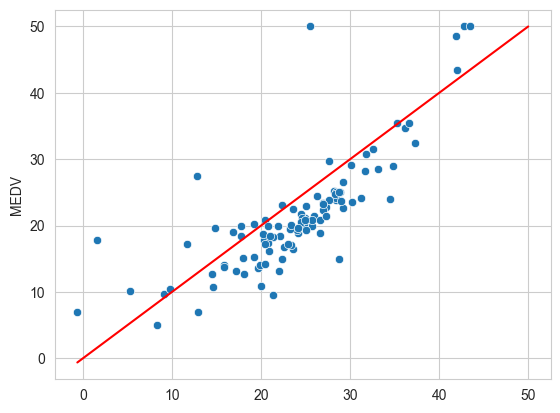

In [135]:
sns.scatterplot(x=y_pred,y=y_test);
plt.plot([min_val, max_val], [min_val, max_val], 'red')
plt.show()

Como hemos mantenido variables que se encuentran correlacionadas, vamos a usar la regulación por regresión LASSO

In [153]:
from sklearn.linear_model import Lasso

lassoR = Lasso(alpha=0.1)
lassoR.fit(X_transformed, y_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(y_train, lm.predict(X_transformed)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(y_test, lm.predict(X_test_transformed)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(y_train, lassoR.predict(X_transformed)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(y_test, lassoR.predict(X_test_transformed)))

Train MSE sin regularización: 26.31
Test MSE sin regularización: 33.54
Train MSE: 27.0254
Test MSE: 31.2709


Volvemos a probar cambiando el valor de alpha

In [160]:
lassoR = Lasso(alpha=0.3)
lassoR.fit(X_transformed, y_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(y_train, lm.predict(X_transformed)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(y_test, lm.predict(X_test_transformed)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(y_train, lassoR.predict(X_transformed)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(y_test, lassoR.predict(X_test_transformed)))

Train MSE sin regularización: 26.31
Test MSE sin regularización: 33.54
Train MSE: 31.9603
Test MSE: 29.8680


Y probamos otro valor de alpha

In [156]:
lassoR = Lasso(alpha=0.2)
lassoR.fit(X_transformed, y_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(y_train, lm.predict(X_transformed)),2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(y_test, lm.predict(X_test_transformed)),2))

print("Train MSE: %0.4f" % metrics.mean_squared_error(y_train, lassoR.predict(X_transformed)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(y_test, lassoR.predict(X_test_transformed)))

Train MSE sin regularización: 26.31
Test MSE sin regularización: 33.54
Train MSE: 28.8760
Test MSE: 29.9209


Se utilizaría un valor de alpha=0.2 porque reduce el error de test sin que se descontrole el error de train. Mejora el modelo de regresión lineal a través de regresión Lasso.